# Animal segmentation

CIFAR-10 is a popular dataset containing 60,000 32x32 color images in 10 different classes, with 6,000 images per class.

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2018/18_3_Keras_CNN_CIFAR_10.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2018/18_3_Keras_CNN_CIFAR_10.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

In [2]:
import pandas as pd
import numpy as np

-----

# The Data

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

In [3]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
x_train[0].shape

(32, 32, 3)

In [6]:
import matplotlib.pyplot as plt

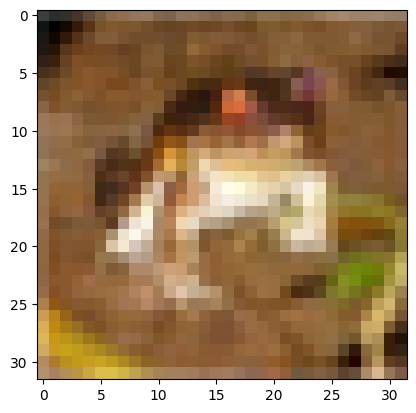

In [7]:
# FROG
plt.imshow(x_train[0])


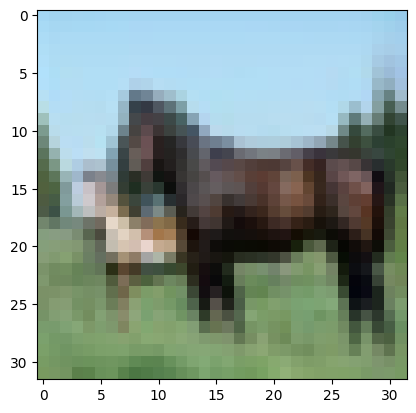

In [8]:
# HORSE
plt.imshow(x_train[12])

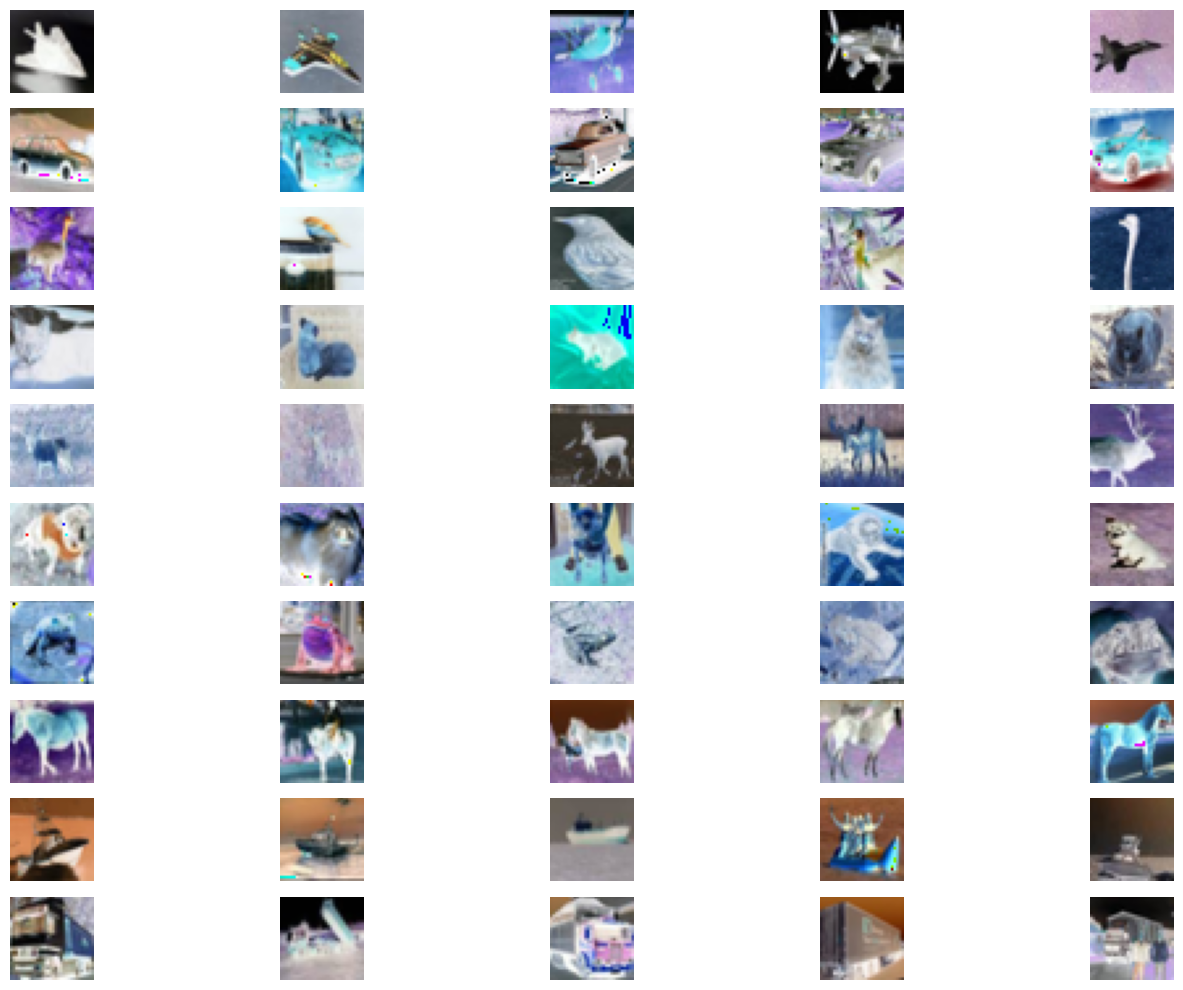

In [9]:
import cv2

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
               'horse', 'ship', 'truck']

def show_images_with_opencv(images, labels, class_names, samples_per_class=5):
    plt.figure(figsize=(15, 10))

    for class_idx, class_name in enumerate(class_names):
        # Find indices of images belonging to the current class
        idxs = np.where(labels.flatten() == class_idx)[0][:samples_per_class]

        for i, idx in enumerate(idxs):
            # Get image and convert RGB to BGR for OpenCV (not necessary here but demonstrating usage)
            img = images[idx]
            img_bgr = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            plt.subplot(len(class_names), samples_per_class, class_idx * samples_per_class + i + 1)
            plt.imshow(img_rgb)
            plt.axis('off')
            if i == 0:
                plt.ylabel(class_name, fontsize=12)
    plt.tight_layout()
    plt.show()

show_images_with_opencv(x_train, y_train, class_names)


# PreProcessing

In [10]:
x_train = x_train/225

In [11]:
x_test = x_test/255

In [12]:
x_train.shape

(50000, 32, 32, 3)

In [13]:
x_test.shape

(10000, 32, 32, 3)

## Labels

In [14]:
from tensorflow.keras.utils import to_categorical

In [15]:
train_labels_cat = to_categorical(y_train, num_classes=10)
test_labels_cat = to_categorical(y_test, num_classes=10)

----------
# Building the Model

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, BatchNormalization, Dropout, Input

In [17]:
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [19]:
history = model.fit(
    x_train, train_labels_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4040 - loss: 1.9115 - val_accuracy: 0.5690 - val_loss: 1.2560
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6260 - loss: 1.0538 - val_accuracy: 0.6714 - val_loss: 0.9455
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6862 - loss: 0.8926 - val_accuracy: 0.6765 - val_loss: 0.9410
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7279 - loss: 0.7805 - val_accuracy: 0.6958 - val_loss: 0.9047
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7476 - loss: 0.7249 - val_accuracy: 0.7650 - val_loss: 0.6818
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7717 - loss: 0.6509 - val_accuracy: 0.7606 - val_loss: 0.6935
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7877 - loss: 0.6010 - val_accuracy: 0.7701 - val_loss: 0.6931
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8058 - loss: 0.5530 - val_accuracy: 

In [20]:
model.save('cnn_cifar10_model.h5')

In [21]:
test_loss, test_accuracy = model.evaluate(x_test, test_labels_cat, verbose=2)
print(f"\nTest accuracy: {test_accuracy:.4f}")

313/313 - 2s - 6ms/step - accuracy: 0.7980 - loss: 0.6030

Test accuracy: 0.7980


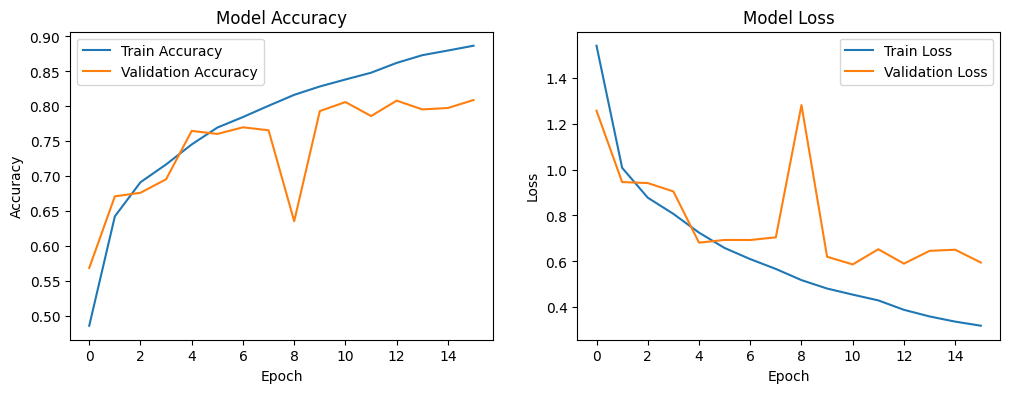

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [23]:
model.save('cnn_cifar10_model.h5')

In [24]:
from sklearn.metrics import classification_report,confusion_matrix

pred = model.predict(x_test)
predictions = pred.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [25]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.79      0.84      0.82      1000
           1       0.88      0.90      0.89      1000
           2       0.71      0.70      0.70      1000
           3       0.66      0.59      0.63      1000
           4       0.76      0.79      0.77      1000
           5       0.73      0.69      0.71      1000
           6       0.78      0.91      0.84      1000
           7       0.89      0.83      0.86      1000
           8       0.92      0.83      0.88      1000
           9       0.86      0.89      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



<Axes: >

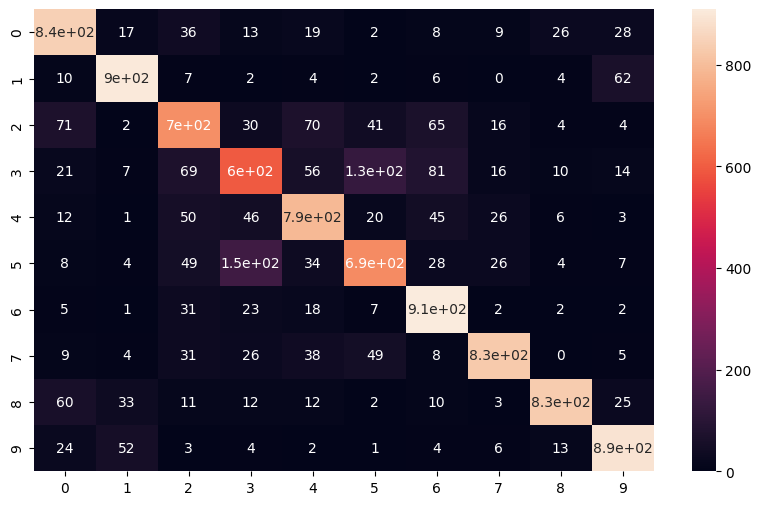

In [26]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True)

# Predicting a given image

In [27]:
my_image = x_test[16]

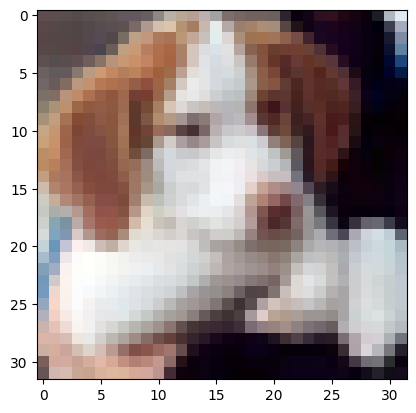

In [28]:
plt.imshow(my_image)

In [29]:
sample = model.predict(my_image.reshape(1,32,32,3))
sample.argmax(axis = -1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step


array([5])

In [30]:
# https://www.cs.toronto.edu/~kriz/cifar.html
def label_name(index):
    lst =  ['airplane','automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse','ship','truck']
    return lst[index]


In [31]:
sample_class = sample.argmax(axis = -1)
label_name(sample_class[0])

'dog'

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2019/Recommendation_Systems.pptx"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>